# IT25300049— Missing data and duplicates
Mahawithana M.A.S.N.M. | 2026-Y2-S1-KU-28


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive')
except ImportError:
    ROOT = Path.cwd()
    if ROOT.name == 'notebooks':
        ROOT = ROOT.parent

# Define output directories
FIG = ROOT / 'results/eda_visualizations'
OUT = ROOT / 'results/outputs'
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Define the NSL-KDD column names directly to avoid requiring column_names.csv
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Set correct file paths directly from My Drive
train_file = ROOT / 'KDDTrain+.txt'
test_file = ROOT / 'KDDTest+.txt'

# Load datasets
train = pd.read_csv(train_file, names=columns)

try:
    test = pd.read_csv(test_file, names=columns)
except FileNotFoundError:
    print("Warning: KDDTest+.txt not found in Google Drive. Initializing an empty DataFrame for testing.")
    test = pd.DataFrame(columns=columns)

print('Train:', train.shape, 'Test:', test.shape)
display(train.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (125973, 43) Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
## 2. Check the data

train.info()
print('Training missing cells:', train.isnull().sum().sum())
print('Test missing cells:', test.isnull().sum().sum())
print('Training full-row duplicates:', train.duplicated().sum())
print('Test full-row duplicates:', test.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

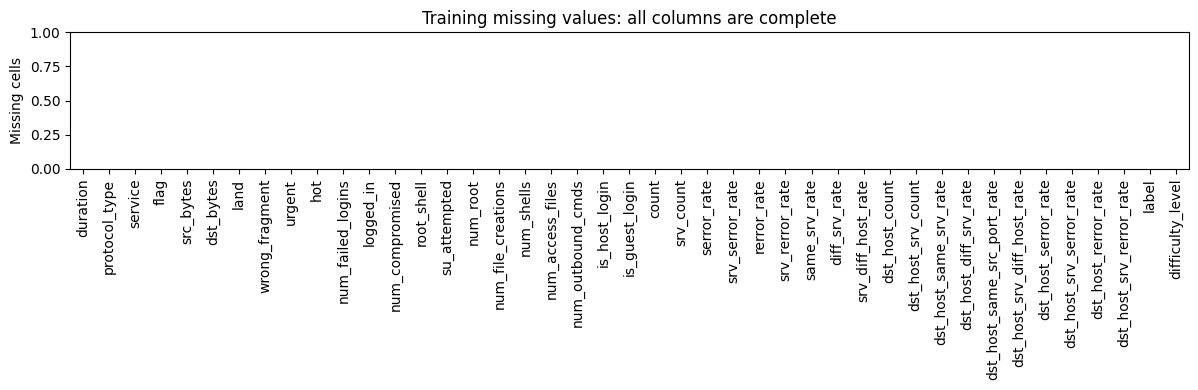

In [ ]:
## 3. Show the missing-value audit

train.isnull().sum().plot.bar(figsize=(12, 4))
plt.title('Training missing values: all columns are complete')
plt.ylabel('Missing cells')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG / '01_missing_values.png', dpi=140, bbox_inches='tight')
plt.show()
